## 3. Описание датасета

Название: Customer Purchases Dataset
Источник: https://www.kaggle.com/datasets/ranaghulamnabi/shopping-behavior-and-preferences-study?resource=download
Предметная область: розничная торговля, маркетинг, потребительское поведение
Характер данных: синтетические или полу-реальные данные о покупках клиентов

Описание:
Датасет содержит информацию о клиентах и их покупках в розничном магазине.
Каждая строка соответствует одному клиенту и одной покупке. Набор данных включает демографические характеристики (возраст, пол, местоположение), атрибуты товара (категория, размер, цвет, сезон) и параметры покупки (сумма, тип товара). Данные могут использоваться для анализа поведения покупателей, сегментации клиентов и задач классификации (например, предсказание категории товара).

**Атрибуты датасета:**

| Название атрибута        | Тип данных       | Описание                                                 |
| ------------------------ | ---------------- | -------------------------------------------------------- |
| `Customer ID`            | целочисленный    | Уникальный идентификатор покупателя                      |
| `Age`                    | целочисленный    | Возраст клиента                                          |
| `Gender`                 | строковый        | Пол клиента                                              |
| `Item Purchased`         | строковый        | Наименование купленного товара                           |
| `Category`               | строковый        | Категория товара (Clothing, Footwear и др.)              |
| `Purchase Amount (USD)`  | числовой         | Сумма покупки в долларах США                             |
| `Location`               | строковый        | Штат/регион проживания покупателя                        |
| `Size`                   | строковый        | Размер купленного товара (S, M, L и т. д.)               |
| `Color`                  | строковый        | Цвет товара                                              |
| `Season`                 | строковый        | Сезон, для которого предназначен товар                   |
| `Review Rating`          | числовой (float) | Оценка товара по отзывам                                 |
| `Subscription Status`    | строковый        | Наличие подписки на рассылку / лояльность (`Yes` / `No`) |
| `Shipping Type`          | строковый        | Тип доставки (Express, Free Shipping, Standard и др.)    |
| `Discount Applied`       | строковый        | Использовалась ли скидка (`Yes` / `No`)                  |
| `Promo Code Used`        | строковый        | Применялся ли промокод                                   |
| `Previous Purchases`     | целочисленный    | Количество предыдущих покупок клиента                    |
| `Payment Method`         | строковый        | Способ оплаты (Cash, Credit Card, PayPal и др.)          |
| `Frequency of Purchases` | строковый        | Частота покупок (Weekly, Monthly, Quarterly и др.)       |

В роли целевого класса выступает 'category'


In [1]:
!pip install pandas
!pip install numpy matplotlib scikit-learn



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report



In [5]:
df = pd.read_csv("shopping_behavior_updated.csv")

In [8]:
df['Category'].value_counts()
df['Category'].value_counts(normalize=True) * 100

Category
Clothing       44.538462
Accessories    31.794872
Footwear       15.358974
Outerwear       8.307692
Name: proportion, dtype: float64

In [10]:
target = 'Category'
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cat_features = X.select_dtypes(include=['object']).columns
num_features = X.select_dtypes(include=['int64','float64']).columns

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

knn_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

print("kNN Accuracy =", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))


=== kNN Accuracy === 0.34487179487179487
              precision    recall  f1-score   support

 Accessories       0.29      0.39      0.33       249
    Clothing       0.42      0.48      0.45       346
    Footwear       0.14      0.04      0.06       122
   Outerwear       0.00      0.00      0.00        63

    accuracy                           0.34       780
   macro avg       0.21      0.23      0.21       780
weighted avg       0.30      0.34      0.31       780



In [14]:
tree_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', DecisionTreeClassifier(
        max_depth=6,
        class_weight='balanced',
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

print("=== Decision Tree Accuracy ===", accuracy_score(y_test, tree_pred))
print(classification_report(y_test, tree_pred, zero_division=0))


=== Decision Tree Accuracy === 0.6807692307692308
              precision    recall  f1-score   support

 Accessories       0.00      0.00      0.00       249
    Clothing       0.58      1.00      0.74       346
    Footwear       1.00      1.00      1.00       122
   Outerwear       1.00      1.00      1.00        63

    accuracy                           0.68       780
   macro avg       0.65      0.75      0.68       780
weighted avg       0.50      0.68      0.56       780



=== kNN Metrics ===
Accuracy: 0.34487179487179487
Precision (macro): 0.2107554373036084
Recall (macro): 0.22858167246832492
F1-score (macro): 0.21090015766547082
              precision    recall  f1-score   support

 Accessories       0.29      0.39      0.33       249
    Clothing       0.42      0.48      0.45       346
    Footwear       0.14      0.04      0.06       122
   Outerwear       0.00      0.00      0.00        63

    accuracy                           0.34       780
   macro avg       0.21      0.23      0.21       780
weighted avg       0.30      0.34      0.31       780



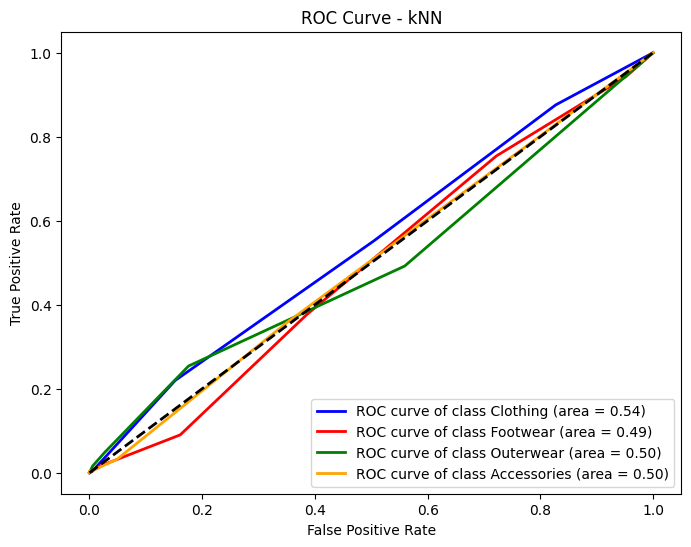

=== Decision Tree Metrics ===
Accuracy: 0.6807692307692308
Precision (macro): 0.6453781512605042
Recall (macro): 0.75
F1-score (macro): 0.68384697130712
              precision    recall  f1-score   support

 Accessories       0.00      0.00      0.00       249
    Clothing       0.58      1.00      0.74       346
    Footwear       1.00      1.00      1.00       122
   Outerwear       1.00      1.00      1.00        63

    accuracy                           0.68       780
   macro avg       0.65      0.75      0.68       780
weighted avg       0.50      0.68      0.56       780



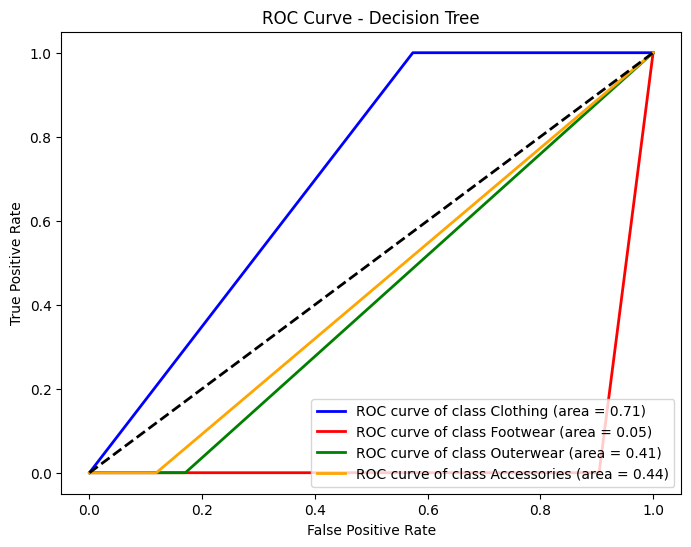

In [16]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_score, recall_score, f1_score
from itertools import cycle

# Преобразуем метки классов для ROC
classes = y.unique()
y_test_bin = label_binarize(y_test, classes=classes)

# Для kNN
knn_prob = knn_model.predict_proba(X_test)  # вероятности для ROC

# Precision, Recall, F1
print("=== kNN Metrics ===")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("Precision (macro):", precision_score(y_test, knn_pred, average='macro', zero_division=0))
print("Recall (macro):", recall_score(y_test, knn_pred, average='macro', zero_division=0))
print("F1-score (macro):", f1_score(y_test, knn_pred, average='macro', zero_division=0))
print(classification_report(y_test, knn_pred, zero_division=0))

# ROC-AUC для многоклассовой задачи
fpr = dict()
tpr = dict()
roc_auc = dict()
for i, class_label in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], knn_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Визуализация ROC
plt.figure(figsize=(8, 6))
colors = cycle(['blue', 'red', 'green', 'orange'])
for i, color in zip(range(len(classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
                   ''.format(classes[i], roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - kNN')
plt.legend(loc='lower right')
plt.show()

tree_prob = tree_model.predict_proba(X_test)

print("=== Decision Tree Metrics ===")
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision (macro):", precision_score(y_test, tree_pred, average='macro', zero_division=0))
print("Recall (macro):", recall_score(y_test, tree_pred, average='macro', zero_division=0))
print("F1-score (macro):", f1_score(y_test, tree_pred, average='macro', zero_division=0))
print(classification_report(y_test, tree_pred, zero_division=0))

# ROC-AUC для Decision Tree
fpr_tree = dict()
tpr_tree = dict()
roc_auc_tree = dict()
for i, class_label in enumerate(classes):
    fpr_tree[i], tpr_tree[i], _ = roc_curve(y_test_bin[:, i], tree_prob[:, i])
    roc_auc_tree[i] = auc(fpr_tree[i], tpr_tree[i])

plt.figure(figsize=(8, 6))
colors = cycle(['blue', 'red', 'green', 'orange'])
for i, color in zip(range(len(classes)), colors):
    plt.plot(fpr_tree[i], tpr_tree[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
                   ''.format(classes[i], roc_auc_tree[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc='lower right')
plt.show()


"""
## 📊 Сводная таблица сравнения моделей классификации

| Метрика | kNN (5 соседей) | Дерево решений (max_depth=6) | Интерпретация (Ключевой вывод) |
| :--- | :--- | :--- | :--- |
| **Accuracy (Общая Точность)** | 0.345 (34.5%) | **0.681 (68.1%)** | Дерево решений вдвое точнее по общему количеству правильных предсказаний. |
| **F1-score (Macro Avg)** | 0.21 | **0.68** | **Лучший показатель баланса.** Дерево решений гораздо лучше справляется с классификацией, учитывая дисбаланс классов. |
| **Recall (Macro Avg)** | 0.23 | **0.75** | Дерево решений лучше находит все реальные случаи каждого класса. |
| **AUC (Clothing)** | 0.54 | **0.71** | Дерево решений гораздо лучше отличает класс "Clothing" от остальных. |
| **AUC (Footwear/Outerwear)**| ~0.50 | **~0.41 / 0.05** | Обе модели, особенно Дерево решений, демонстрируют провал в ранжировании этих классов. |

"""